##
Unemployment in India — Data Cleaning, EDA, and COVID-19 Impact Analysis
===========================================================================
Dataset: Unemployment_in_India.csv (May 2019 – June 2020, 28 states/UTs,
monthly, split by Rural/Urban area)

##

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD DATA
# ============================================================

In [54]:
df = pd.read_csv("Unemployment in India.csv")

In [55]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [57]:
df.shape

(768, 7)

# ============================================================ 
# 2. CLEAN DATA 
# ============================================================

In [58]:
# Remove spaces from column names
df.columns = df.columns.str.strip()

In [59]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [60]:
# Remove completely all empty rows
df = df.dropna(how="all")

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
# running duplicates rows for safety
df = df.drop_duplicates()

In [63]:
# Remove extra spaces from text columns
df["Region"] = df["Region"].str.strip()
df["Date"] = df["Date"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()
df["Area"] = df["Area"].str.strip()

In [64]:
# Convert Date column type to datetime type
df["Date"] = pd.to_datetime(df["Date"], format = "%d-%m-%Y")

In [65]:
df["Date"]

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
749   2020-02-29
750   2020-03-31
751   2020-04-30
752   2020-05-31
753   2020-06-30
Name: Date, Length: 740, dtype: datetime64[ns]

In [66]:
# Create Year and Month columns

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

In [67]:
df.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


In [68]:
# Sort data
df = df.sort_values(["Region", "Area", "Date"])

In [69]:
# Remove Frequency because it contains the same value
df = df.drop("Frequency", axis = 1)

# ============================================================ 
# 3. CHECK DATA 
# ============================================================

In [70]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 740
Number of columns: 9


In [71]:
print("\nStates/UTs:")
print(df["Region"].nunique())


States/UTs:
28


In [72]:
print("\nAreas:")
print(df["Area"].unique())


Areas:
['Rural' 'Urban']


In [73]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Region                                     0
Date                                       0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
Year                                       0
Month                                      0
Month_Name                                 0
dtype: int64


In [74]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        7.400000e+02                               740.000000   
mean         7.204460e+06                                42.630122   
min          4.942000e+04                                13.330000   
25%          1.190404e+06                

In [75]:
# Save cleaned data 
df.to_csv("Unemployment_in_India_cleaned.csv", index=False)

# ============================================================ 
# 4. CREATE COVID PERIOD 
# ============================================================

In [76]:
covid_date = pd.Timestamp("2020-03-25")

df["Period"] = np.where(
    df["Date"]>=covid_date,
    "Covid",
    "Pre-Covid"
)

In [77]:
df

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Period
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,2019,5,May,Pre-Covid
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural,2019,6,June,Pre-Covid
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural,2019,7,July,Pre-Covid
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural,2019,8,August,Pre-Covid
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural,2019,9,September,Pre-Covid
...,...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,7.55,10871168.0,44.09,Urban,2020,2,February,Pre-Covid
750,West Bengal,2020-03-31,6.67,10806105.0,43.34,Urban,2020,3,March,Covid
751,West Bengal,2020-04-30,15.63,9299466.0,41.20,Urban,2020,4,April,Covid
752,West Bengal,2020-05-31,15.22,9240903.0,40.67,Urban,2020,5,May,Covid


# ============================================================
# 5. NATIONAL UNEMPLOYMENT TREND 
# ============================================================

In [78]:
monthly = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()
monthly

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

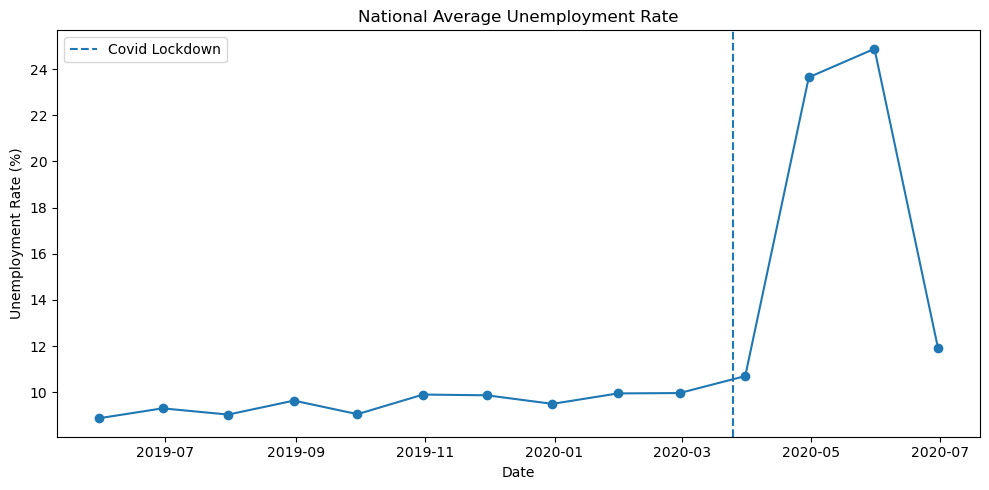

In [79]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.axvline(
    covid_date,
    linestyle="--",
    label = "Covid Lockdown"
)

plt.title("National Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout() 
plt.savefig("01_national_trend.png") 
plt.show()

# ============================================================ 
# 6. RURAL VS URBAN 
# ============================================================

In [80]:
area_data = df.groupby(["Date","Area"])["Estimated Unemployment Rate (%)"].mean().reset_index()
area_data

,Date,Area,Estimated Unemployment Rate (%)
0,2019-05-31,Rural,7.068077
1,2019-05-31,Urban,10.551429
2,2019-06-30,Rural,8.201154
3,2019-06-30,Urban,10.326786
4,2019-07-31,Rural,7.741923
5,2019-07-31,Urban,10.233571
6,2019-08-31,Rural,8.503077
7,2019-08-31,Urban,10.730741
8,2019-09-30,Rural,7.036800
9,2019-09-30,Urban,10.917407


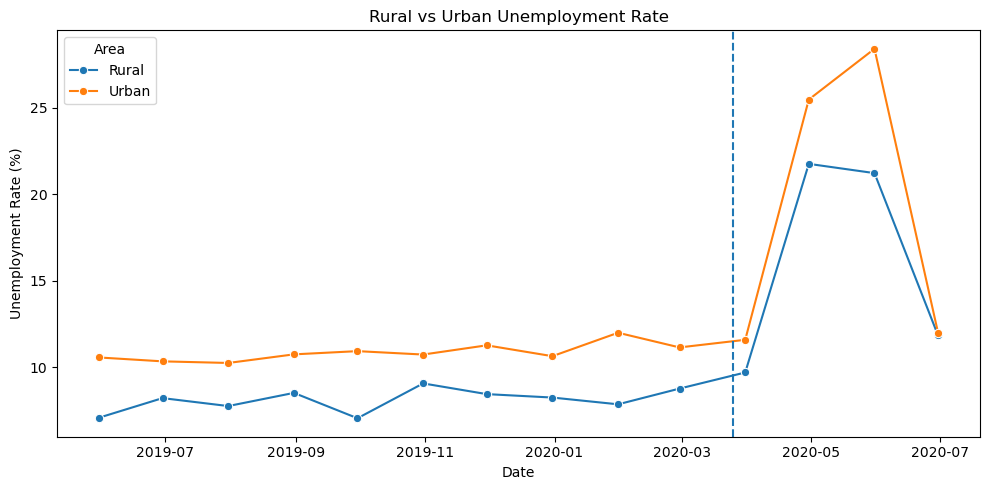

In [81]:
plt.figure(figsize=(10,5))

sns.lineplot(data=area_data, x="Date", y="Estimated Unemployment Rate (%)",
             hue="Area", marker="o")

plt.axvline(covid_date, linestyle="--")

plt.title("Rural vs Urban Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("02_rural_vs_urban.png")
plt.show()

# ============================================================ 
# 7. COVID IMPACT BY STATE 
# ============================================================

In [82]:
state_period = df.groupby(["Region","Period"])["Estimated Unemployment Rate (%)"].mean().unstack()
state_period

Period,Covid,Pre-Covid
Region,,
Andhra Pradesh,13.576250,5.037500
Assam,6.578571,6.372632
Bihar,31.631250,13.833000
Chandigarh,14.325000,16.325000
Chhattisgarh,13.075000,7.706500
Delhi,22.157500,14.230500
Goa,13.107500,8.507500
Gujarat,10.383750,5.176000
Haryana,34.652500,22.935500


In [83]:
# Calculate Change

state_period["Change"] = (
    state_period["Covid"] - state_period["Pre-Covid"]
)
state_period = state_period.sort_values(
    "Change",
    ascending=False
)
print("\n===== COVID IMPACT BY STATE =====")
print(state_period)


===== COVID IMPACT BY STATE =====
Period                Covid  Pre-Covid     Change
Region                                           
Puducherry        38.955000   1.593000  37.362000
Tamil Nadu        25.403750   2.836500  22.567250
Jharkhand         36.348750  14.279500  22.069250
Bihar             31.631250  13.833000  17.798250
Karnataka         15.280000   3.234500  12.045500
Haryana           34.652500  22.935500  11.717000
Kerala            17.952500   6.992500  10.960000
Telangana         15.442500   4.656000  10.786500
Madhya Pradesh    14.070000   4.741000   9.329000
Andhra Pradesh    13.576250   5.037500   8.538750
Delhi             22.157500  14.230500   7.927000
Odisha            11.281250   3.408500   7.872750
Maharashtra       13.026250   5.370000   7.656250
Uttar Pradesh     17.382500  10.619000   6.763500
West Bengal       12.011250   6.570000   5.441250
Chhattisgarh      13.075000   7.706500   5.368500
Gujarat           10.383750   5.176000   5.207750
Goa            

# ============================================================ 
# 8. TOP 15 STATES AFFECTED 
# ============================================================

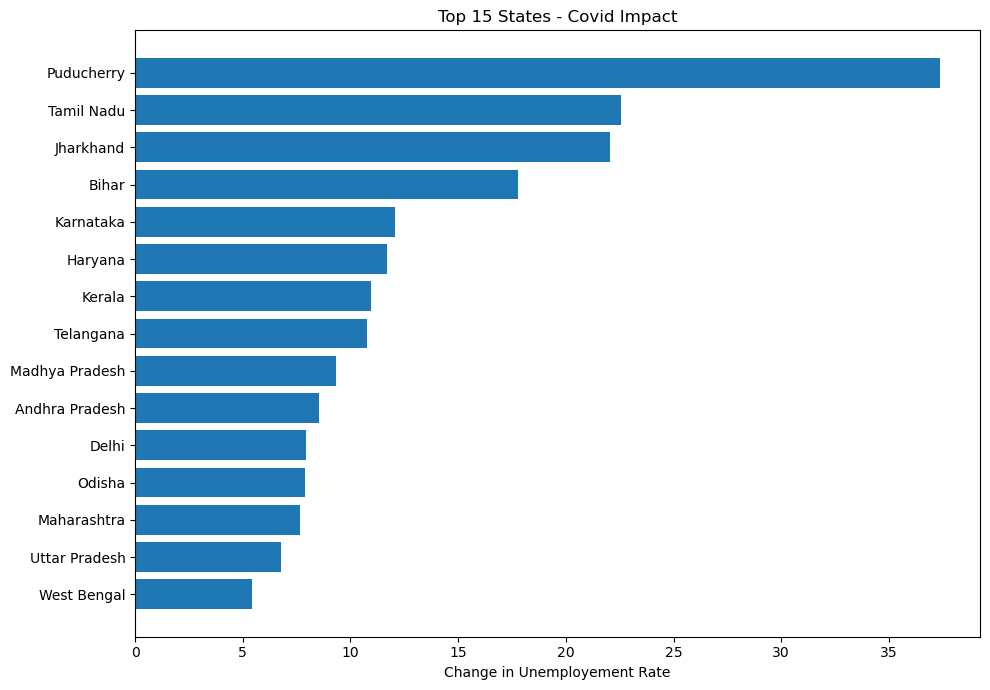

In [84]:
top_states = state_period.head(15)

plt.figure(figsize=(10,7))

plt.barh(top_states.index[::-1], top_states["Change"][::-1])

plt.title("Top 15 States - Covid Impact")
plt.xlabel("Change in Unemployement Rate")
plt.tight_layout()
plt.savefig("03_state_covid_impact.png")
plt.show()

In [85]:
# Save state COVID analysis 
state_period.to_csv("state_covid_impact.csv")

# ============================================================ 
# 9. STATE VS MONTH HEATMAP 
# ============================================================

In [86]:
pivot= df.pivot_table(index="Region",
                     columns="Month_Name",
                     values="Estimated Unemployment Rate (%)",
                     aggfunc="mean")
pivot

Month_Name,April,August,December,February,January,July,June,March,May,November,October,September
Region,,,,,,,,,,,,
Andhra Pradesh,24.295,3.965,6.130,5.785,5.975,4.695,3.390000,6.970,12.277500,5.830,4.110,5.590
Assam,8.370,8.090,5.020,6.620,5.765,3.735,4.597500,7.055,8.077500,5.485,7.910,6.860
Bihar,51.930,14.330,12.535,12.360,14.910,14.925,14.107500,15.560,28.575000,15.010,13.265,14.665
Chandigarh,NaN,9.520,8.330,16.670,20.000,21.800,9.810000,21.430,18.350000,22.050,13.990,20.140
Chhattisgarh,10.065,5.465,4.840,8.840,9.450,6.355,13.935000,7.760,12.832500,5.545,8.615,8.895
Delhi,18.600,15.350,14.020,14.335,17.965,12.875,15.335000,16.135,23.352500,13.610,14.125,16.545
Goa,13.835,3.440,9.880,2.155,8.150,11.630,9.390000,4.760,8.553333,24.455,9.760,3.385
Gujarat,18.970,3.950,4.585,6.340,5.585,4.865,4.257500,6.490,8.292500,6.105,5.180,6.125
Haryana,44.250,27.565,26.605,25.240,21.725,20.835,27.120000,25.530,27.972500,21.825,22.605,21.600


In [87]:
# Keeping months in date order
month_order= (
    df[["Date", "Month_Name"]].drop_duplicates().sort_values("Date")["Month_Name"]
)


In [88]:
pivot = pivot[month_order]

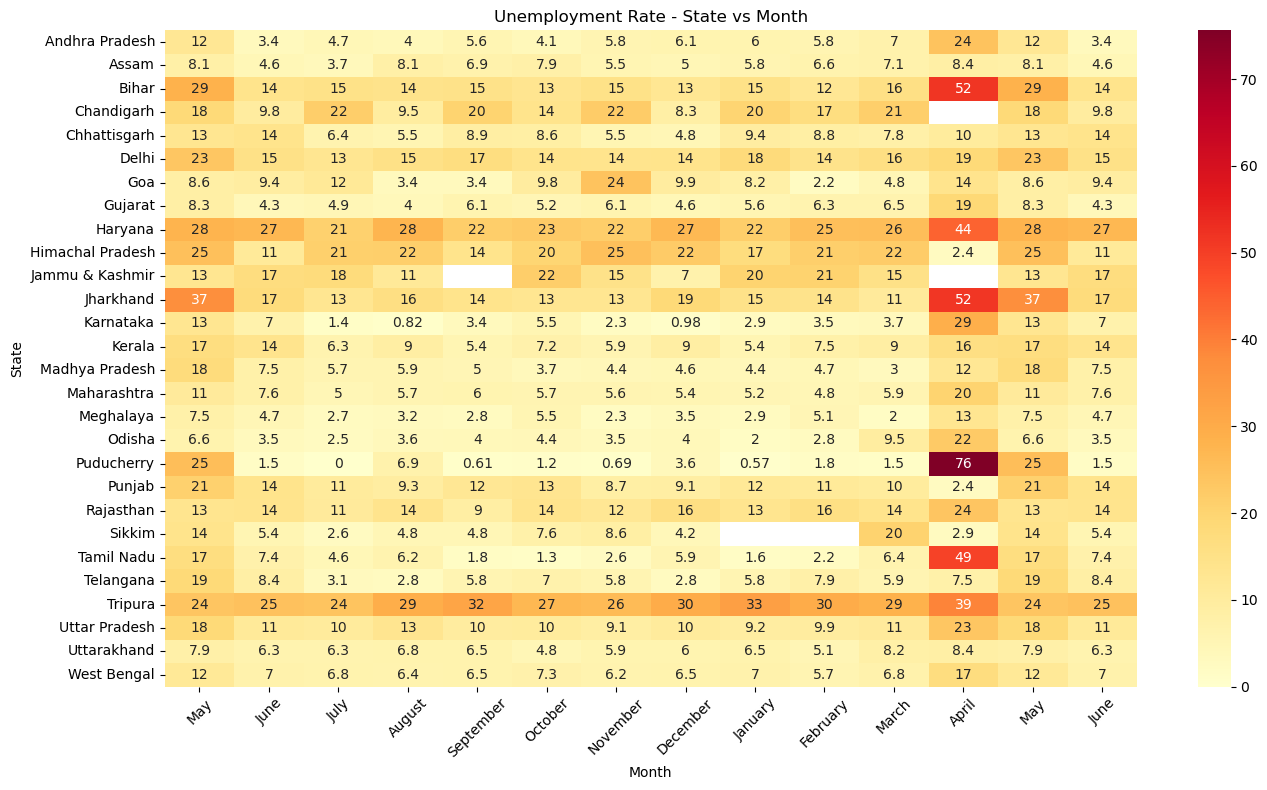

In [89]:
plt.figure(figsize=(14,8))

sns.heatmap(pivot, cmap="YlOrRd", annot=True)

plt.title("Unemployment Rate - State vs Month")
plt.xlabel("Month")
plt.ylabel("State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("04_state_month_heatmap.png")
plt.show()

# ============================================================ 
# 10. SEASONAL PATTERN 
# ============================================================

In [90]:
pre_covid = df[df["Period"]== "Pre-Covid"].copy()

season = pre_covid.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

In [91]:
season

Month
1     9.950755
2     9.964717
5     8.874259
6     9.303333
7     9.033889
8     9.637925
9     9.051731
10    9.900909
11    9.868364
12    9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

In [92]:
months = [ "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec" ]

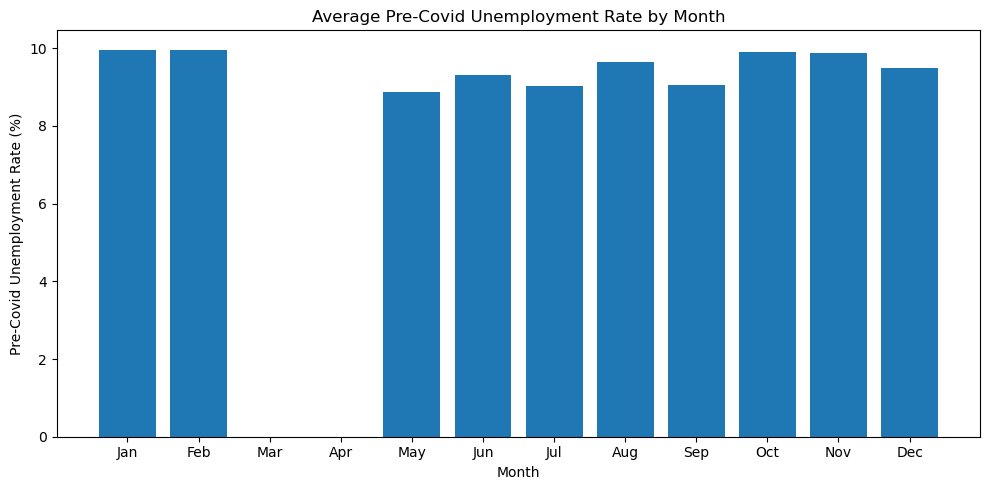

In [93]:
plt.figure(figsize=(10,5))

plt.bar(season.index, season.values)

plt.title("Average Pre-Covid Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Pre-Covid Unemployment Rate (%)")
plt.xticks(range(1,13),months)
plt.tight_layout()
plt.savefig("05_seasonality.png")
plt.show()

# ============================================================ 
# 11. LABOUR PARTICIPATION VS UNEMPLOYMENT # ============================================================

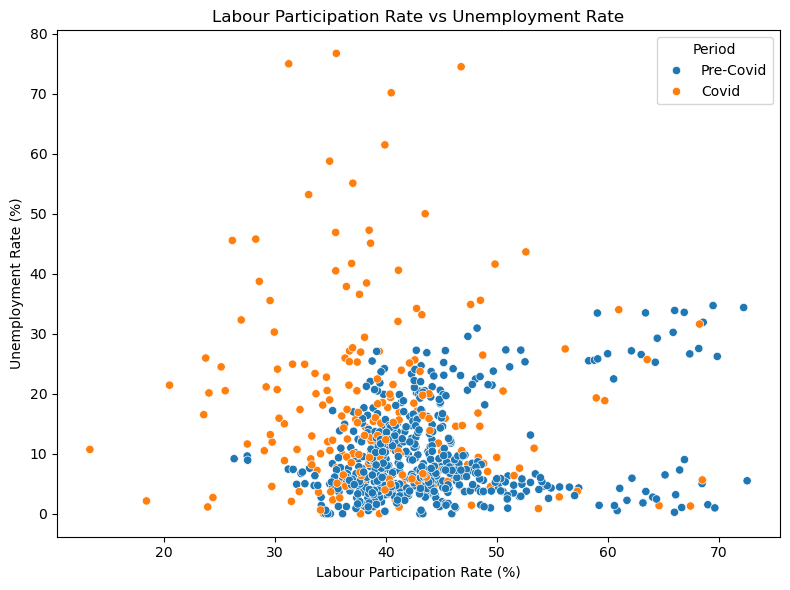

In [94]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Estimated Labour Participation Rate (%)",
                y="Estimated Unemployment Rate (%)", hue="Period")

plt.title("Labour Participation Rate vs Unemployment Rate")

plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("06_LPR_vs_UnemploymentR.png")
plt.show()

In [95]:
# Calculate correlation 
correlation = df[ [ "Estimated Labour Participation Rate (%)", 
                   "Estimated Unemployment Rate (%)" ] ].corr().iloc[0, 1] 
print("\nCorrelation:")
print(round(correlation, 2))


Correlation:
0.0


# ============================================================ 
# 12. AVERAGE UNEMPLOYMENT BY STATE 
# ============================================================

In [96]:
state_average = df.groupby("Region")[ "Estimated Unemployment Rate (%)"].mean().sort_values()
state_average

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

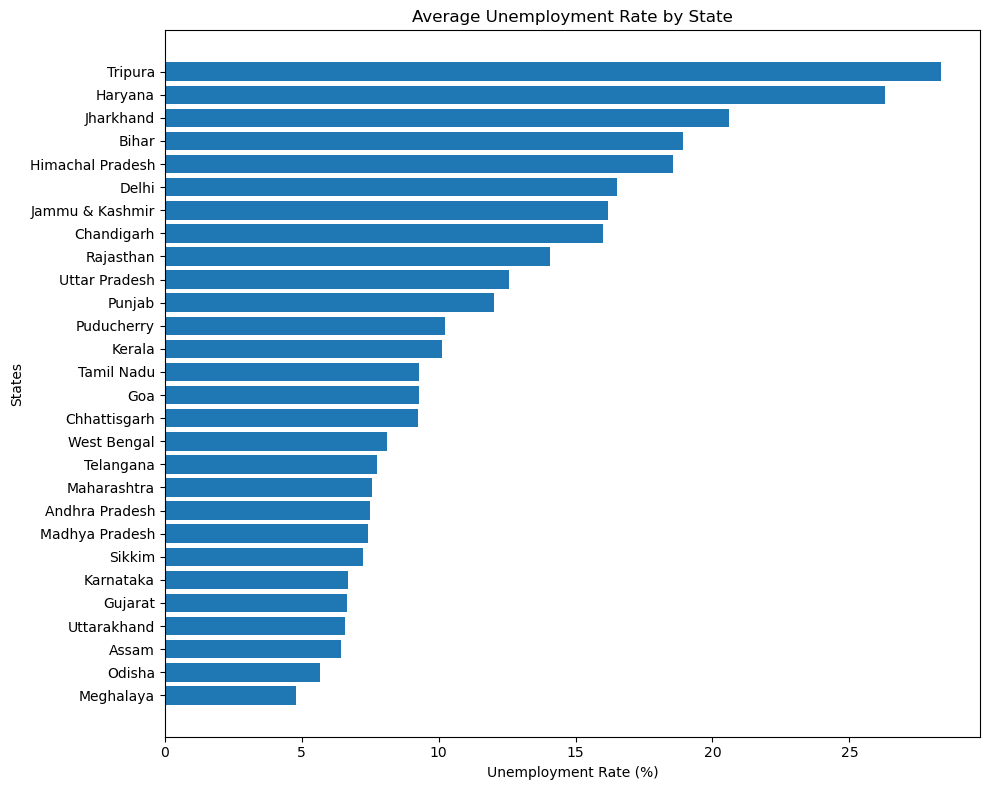

In [97]:
plt.figure(figsize=(10,8))

plt.barh(state_average.index,state_average.values)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("States")
plt.tight_layout()
plt.savefig("07_state_average.png")
plt.show()

# ============================================================ 
# 13. PRE-COVID VS COVID AVERAGE 
# ============================================================

In [104]:
pre_covid_avg = df[df["Period"]=="Pre-Covid"]["Estimated Unemployment Rate (%)"].mean()


In [105]:
covid_avg = df[df["Period"]=="Covid"]["Estimated Unemployment Rate (%)"].mean()

In [106]:
change = covid_avg - pre_covid_avg
print("\n===== COVID SUMMARY =====")

print(
    "Pre-Covid Average:", round(pre_covid_avg,2), "%"
)

print(
    "Covid Average:", round(covid_avg,2), "%"
)

print(
    "Change:", round(change, 2), "percentage points"
)


===== COVID SUMMARY =====
Pre-Covid Average: 9.51 %
Covid Average: 17.77 %
Change: 8.26 percentage points


# ============================================================ 
# 14. HIGHEST UNEMPLOYMENT READING 
# ============================================================

In [108]:
highest = df.loc[df["Estimated Unemployment Rate (%)"].idxmax()]

print("\n===== HIGHEST UNEMPLOYMENT =====")

print("State:", highest["Region"])
print("Area:", highest["Area"])
print("Rate:", highest["Estimated Unemployment Rate (%)"])
print("Date:", highest["Date"])


===== HIGHEST UNEMPLOYMENT =====
State: Puducherry
Area: Urban
Rate: 76.74
Date: 2020-04-30 00:00:00


# ============================================================ 
# 15. RURAL VS URBAN Pre-Covid & COVID COMPARISON 
# ============================================================

In [109]:
print("\n===== RURAL VS URBAN =====")

for period in ["Pre-Covid", "Covid"]:
    data = df[df["Period"]==period]

    rural = data[data["Area"]== "Rural"]["Estimated Unemployment Rate (%)"].mean()

    urban = data[data["Area"]== "Urban"]["Estimated Unemployment Rate (%)"].mean()

    print("\n", period)

    print("Rural:", round(rural, 2), "%")

    print("Urban:", round(urban, 2), "%")


===== RURAL VS URBAN =====

 Pre-Covid
Rural: 8.09 %
Urban: 10.84 %

 Covid
Rural: 16.18 %
Urban: 19.28 %


# ============================================================ 
# 16. TOP 5 STATES WITH COVID INCREASE 
# ============================================================

In [110]:
print("\n===== TOP 5 STATES =====")

print(state_period["Change"].head(5).round(2))

print("\nAnalysis completed successfully!")

print( "Cleaned data saved as: " "Unemployment_in_India_cleaned.csv" )

print( "Charts saved as PNG files." )


===== TOP 5 STATES =====
Region
Puducherry    37.36
Tamil Nadu    22.57
Jharkhand     22.07
Bihar         17.80
Karnataka     12.05
Name: Change, dtype: float64

Analysis completed successfully!
Cleaned data saved as: Unemployment_in_India_cleaned.csv
Charts saved as PNG files.
